# 🎥 YouTube Long-Form Videos Analytics & Drive Exporter

This Google Colab notebook fetches titles, metrics, and metadata for the last **50 long-form videos** of any specified YouTube channel, exports the dataset to **Google Drive** in CSV and JSON formats, and generates comprehensive visual charts.

### Key Features:
- **Quota Efficient**: Uses YouTube Data API v3 (`channels`, `playlistItems`, `videos`) **without using expensive search endpoints**.
- **Shorts Filtering**: Leverages YouTube's long-form uploads playlist ID (`UULF` prefix) combined with ISO 8601 duration checks (>60s).
- **Google Drive Integration**: Automatically mounts Google Drive and saves structured datasets (`.csv` and `.json`).
- **Rich Visualizations**: Generates performance, engagement, duration, and publishing timing charts using Seaborn and Matplotlib.

## ⚙️ 1. Configuration & Setup

Set your YouTube API Key and Channel details below.
- **API Key**: You can store it in Colab Secrets (`YOUTUBE_API_KEY`) or paste it directly in `CONFIG["YOUTUBE_API_KEY"]` below.
- **Channel Identifier**: Can be a Channel Handle (e.g., `@MKBHD`), Channel ID (e.g., `UCBJycSMrsT5N546JbDA6AGg`), or Username.

In [7]:
# Install required packages if missing
!pip install -q google-api-python-client pandas matplotlib seaborn

import os
import re
import json
import math
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from googleapiclient.discovery import build

# Try loading API key from Colab Secrets if available
colab_api_key = ""
try:
    from google.colab import userdata
    colab_api_key = userdata.get('YOUTUBE_API_KEY')
except Exception:
    pass

# User Configuration
CONFIG = {
    "YOUTUBE_API_KEY": colab_api_key or "YOUR_YOUTUBE_API_KEY_HERE",
    "CHANNEL_IDENTIFIER": "@josemillanastrologohumanista",  # Channel Handle (@name), Channel ID (UC...), or Username
    "TARGET_VIDEO_COUNT": 50,         # Number of long-form videos to collect
    "DRIVE_OUTPUT_DIR": "/content/drive/MyDrive/YouTube_Analytics",
    "MOUNT_DRIVE": True                # Set to True when running in Google Colab
}

print("Configuration loaded.")
if CONFIG["YOUTUBE_API_KEY"] in ["", "YOUR_YOUTUBE_API_KEY_HERE"]:
    print("⚠️ WARNING: Please set your YOUTUBE_API_KEY before running data fetching cells!")

Configuration loaded.


## 💾 2. Mount Google Drive

Mount Google Drive to persist output CSV and JSON files.

In [8]:
if CONFIG["MOUNT_DRIVE"]:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        os.makedirs(CONFIG["DRIVE_OUTPUT_DIR"], exist_ok=True)
        print(f"✅ Google Drive mounted successfully! Output directory: {CONFIG['DRIVE_OUTPUT_DIR']}")
    except Exception as e:
        print(f"ℹ️ Could not mount Google Drive automatically ({e}). Local directory will be used.")
        CONFIG["DRIVE_OUTPUT_DIR"] = "./output"
        os.makedirs(CONFIG["DRIVE_OUTPUT_DIR"], exist_ok=True)
else:
    os.makedirs(CONFIG["DRIVE_OUTPUT_DIR"], exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully! Output directory: /content/drive/MyDrive/YouTube_Analytics


## 🔍 3. YouTube API Client & Helper Functions

In [9]:
def get_youtube_client(api_key):
    """Initializes YouTube Data API client."""
    return build('youtube', 'v3', developerKey=api_key)

def parse_iso8601_duration(duration_str):
    """Parses ISO 8601 duration string (e.g. PT1H2M3S) into total seconds."""
    pattern = re.compile(r'PT(?:(?P<hours>\d+)H)?(?:(?P<minutes>\d+)M)?(?:(?P<seconds>\d+)S)?')
    match = pattern.match(duration_str)
    if not match:
        return 0
    parts = match.groupdict()
    hours = int(parts['hours']) if parts['hours'] else 0
    minutes = int(parts['minutes']) if parts['minutes'] else 0
    seconds = int(parts['seconds']) if parts['seconds'] else 0
    return hours * 3600 + minutes * 60 + seconds

def format_seconds(seconds):
    """Formats duration in seconds to HH:MM:SS or MM:SS."""
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60
    if hours > 0:
        return f"{hours}:{minutes:02d}:{secs:02d}"
    return f"{minutes}:{secs:02d}"

def get_channel_info(youtube, identifier):
    """
    Resolves channel details using `channels.list` without search endpoints.
    Supports Handle (@name), Channel ID (UC...), or Username.
    """
    identifier = identifier.strip()
    res = None

    if identifier.startswith("@"):
        res = youtube.channels().list(part="snippet,contentDetails,statistics", forHandle=identifier).execute()
    elif identifier.startswith("UC"):
        res = youtube.channels().list(part="snippet,contentDetails,statistics", id=identifier).execute()
    else:
        res = youtube.channels().list(part="snippet,contentDetails,statistics", forUsername=identifier).execute()
        if not res.get("items"):
            # Fallback trying as channel ID
            res = youtube.channels().list(part="snippet,contentDetails,statistics", id=identifier).execute()

    if not res.get("items"):
        raise ValueError(f"Could not find channel for identifier: '{identifier}'. Check your input.")

    channel_item = res["items"][0]
    channel_id = channel_item["id"]
    uploads_playlist_id = channel_item["contentDetails"]["relatedPlaylists"]["uploads"]

    # Construct Long-Form Uploads Playlist ID using UULF prefix
    # UC... -> UULF...
    # UU... -> UULF...
    if uploads_playlist_id.startswith("UU"):
        longform_playlist_id = "UULF" + uploads_playlist_id[2:]
    elif channel_id.startswith("UC"):
        longform_playlist_id = "UULF" + channel_id[2:]
    else:
        longform_playlist_id = uploads_playlist_id

    info = {
        "channel_id": channel_id,
        "title": channel_item["snippet"]["title"],
        "custom_url": channel_item["snippet"].get("customUrl", ""),
        "subscriber_count": channel_item["statistics"].get("subscriberCount", 0),
        "video_count": channel_item["statistics"].get("videoCount", 0),
        "uploads_playlist_id": uploads_playlist_id,
        "longform_playlist_id": longform_playlist_id
    }
    return info

## 📥 4. Fetch Long-Form Videos Data

We query the channel's `UULF` playlist ID via `playlistItems.list` and retrieve full statistics & duration via `videos.list`. Videos <= 60 seconds (Shorts) are filtered out automatically.

In [10]:
def fetch_last_n_longform_videos(youtube, playlist_id, fallback_playlist_id, target_count=50):
    """
    Fetches videos from playlist_id (UULF). If UULF playlist returns empty (rare),
    falls back to default uploads playlist (UU) with strict duration filtering (>60s).
    """
    videos_data = []
    next_page_token = None
    current_playlist_id = playlist_id

    print(f"Fetching video items from playlist ID: {current_playlist_id}...")

    # Try fetching with primary playlist
    while len(videos_data) < target_count:
        try:
            pl_req = youtube.playlistItems().list(
                part="snippet,contentDetails",
                playlistId=current_playlist_id,
                maxResults=min(50, (target_count - len(videos_data)) * 3),
                pageToken=next_page_token
            )
            pl_res = pl_req.execute()
        except Exception as e:
            if current_playlist_id != fallback_playlist_id:
                print(f"⚠️ UULF playlist fetch issue ({e}). Falling back to main uploads playlist {fallback_playlist_id}...")
                current_playlist_id = fallback_playlist_id
                next_page_token = None
                continue
            else:
                raise e

        items = pl_res.get("items", [])
        if not items and len(videos_data) == 0 and current_playlist_id != fallback_playlist_id:
            print(f"⚠️ UULF playlist returned 0 items. Falling back to main uploads playlist {fallback_playlist_id}...")
            current_playlist_id = fallback_playlist_id
            next_page_token = None
            continue

        if not items:
            break

        # Extract video IDs
        video_ids = [item["contentDetails"]["videoId"] for item in items]

        # Get detailed metrics & contentDetails (duration) for these videos
        v_req = youtube.videos().list(
            part="snippet,contentDetails,statistics",
            id=",".join(video_ids)
        )
        v_res = v_req.execute()

        for v_item in v_res.get("items", []):
            duration_iso = v_item["contentDetails"]["duration"]
            duration_sec = parse_iso8601_duration(duration_iso)

            # Filter out Shorts (duration <= 60 seconds)
            if duration_sec <= 60:
                continue

            snippet = v_item["snippet"]
            stats = v_item.get("statistics", {})

            v_data = {
                "video_id": v_item["id"],
                "title": snippet.get("title"),
                "published_at": snippet.get("publishedAt"),
                "duration_iso": duration_iso,
                "duration_seconds": duration_sec,
                "duration_formatted": format_seconds(duration_sec),
                "view_count": int(stats.get("viewCount", 0)),
                "like_count": int(stats.get("likeCount", 0)),
                "comment_count": int(stats.get("commentCount", 0)),
                "thumbnail_url": snippet.get("thumbnails", {}).get("high", {}).get("url", ""),
                "url": f"https://www.youtube.com/watch?v={v_item['id']}"
            }
            videos_data.append(v_data)
            if len(videos_data) >= target_count:
                break

        next_page_token = pl_res.get("nextPageToken")
        if not next_page_token:
            break

    return videos_data[:target_count]

# Execute Data Fetching
youtube = get_youtube_client(CONFIG["YOUTUBE_API_KEY"])
channel_info = get_channel_info(youtube, CONFIG["CHANNEL_IDENTIFIER"])
print(f"Channel Identified: {channel_info['title']} (ID: {channel_info['channel_id']})")
print(f"Subscribers: {int(channel_info['subscriber_count']):,} | Total Videos: {int(channel_info['video_count']):,}")

raw_videos = fetch_last_n_longform_videos(
    youtube,
    playlist_id=channel_info["longform_playlist_id"],
    fallback_playlist_id=channel_info["uploads_playlist_id"],
    target_count=CONFIG["TARGET_VIDEO_COUNT"]
)

print(f"Successfully fetched {len(raw_videos)} long-form videos.")

Channel Identified: José Millán Astrología Humanística (ID: UCHET87SSkPuh5aybA-e1u0w)
Subscribers: 307,000 | Total Videos: 890
Fetching video items from playlist ID: UULFHET87SSkPuh5aybA-e1u0w...
Successfully fetched 50 long-form videos.


## 📊 5. Data Processing & Google Drive Export

In [11]:
df = pd.DataFrame(raw_videos)

# Derived columns
df['published_at_dt'] = pd.to_datetime(df['published_at'])
df['publish_date'] = df['published_at_dt'].dt.date
df['publish_day_of_week'] = df['published_at_dt'].dt.day_name()
df['publish_hour_utc'] = df['published_at_dt'].dt.hour

# Engagement Ratios
df['likes_per_1k_views'] = (df['like_count'] / df['view_count'] * 1000).fillna(0).round(2)
df['comments_per_1k_views'] = (df['comment_count'] / df['view_count'] * 1000).fillna(0).round(2)
df['engagement_rate_%'] = (((df['like_count'] + df['comment_count']) / df['view_count']) * 100).fillna(0).round(2)

# Export Paths
safe_channel_title = re.sub(r'[^a-zA-Z0-9_-]', '_', channel_info['title'])
csv_path = os.path.join(CONFIG["DRIVE_OUTPUT_DIR"], f"{safe_channel_title}_last_{len(df)}_longform_videos.csv")
json_path = os.path.join(CONFIG["DRIVE_OUTPUT_DIR"], f"{safe_channel_title}_last_{len(df)}_longform_videos.json")

# Save CSV and JSON
df.to_csv(csv_path, index=False)

export_json_data = {
    "channel": channel_info,
    "fetched_at": datetime.datetime.utcnow().isoformat() + "Z",
    "video_count": len(df),
    "videos": raw_videos
}
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(export_json_data, f, indent=2, ensure_ascii=False)

print(f"📁 Data successfully saved to Google Drive:")
print(f"   - CSV: {csv_path}")
print(f"   - JSON: {json_path}")

# Display Preview
cols_to_display = ['title', 'publish_date', 'duration_formatted', 'view_count', 'like_count', 'engagement_rate_%']
df[cols_to_display].head(10)

📁 Data successfully saved to Google Drive:
   - CSV: /content/drive/MyDrive/YouTube_Analytics/Jos__Mill_n_Astrolog_a_Human_stica_last_50_longform_videos.csv
   - JSON: /content/drive/MyDrive/YouTube_Analytics/Jos__Mill_n_Astrolog_a_Human_stica_last_50_longform_videos.json


/tmp/ipykernel_961/1124581073.py:24: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "fetched_at": datetime.datetime.utcnow().isoformat() + "Z",


,title,publish_date,duration_formatted,view_count,like_count,engagement_rate_%
0,La hora de los monstruos. La astrología de la ...,2026-09-27,1:15:10,172149,7753,4.86
1,La cometa alza el vuelo. La astrología de la s...,2026-09-11,1:00:33,195561,7646,4.18
2,Sé tu propio médico,2026-08-29,1:00:29,183952,7488,4.34
3,Tiempo de finales. La astrología de la segunda...,2026-08-15,53:23,167126,9333,5.94
4,La caída de los dioses. La astrología de agost...,2026-08-01,1:18:41,164275,9657,6.24
5,La dichosa canasta,2026-07-25,1:11:32,93400,6571,7.50
6,200 años de Aire,2026-07-18,1:07:28,78261,5779,7.82
7,Una canción de Aire y Fuego. La astrología de ...,2026-07-12,1:14:59,105670,7665,7.73
8,En el ojo de la tormenta. La astrología del me...,2026-06-26,1:15:47,154049,8570,5.92
9,Para qué sirve la astrología,2026-06-21,34:49,41317,4100,10.65


## 📈 6. Visualizations & Analytics

Below are 5 key charts providing deep insights into channel performance, video lengths, engagement, and publishing schedules.

/tmp/ipykernel_961/2075797857.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="view_count", y="title", data=top_10, palette="Blues_r")


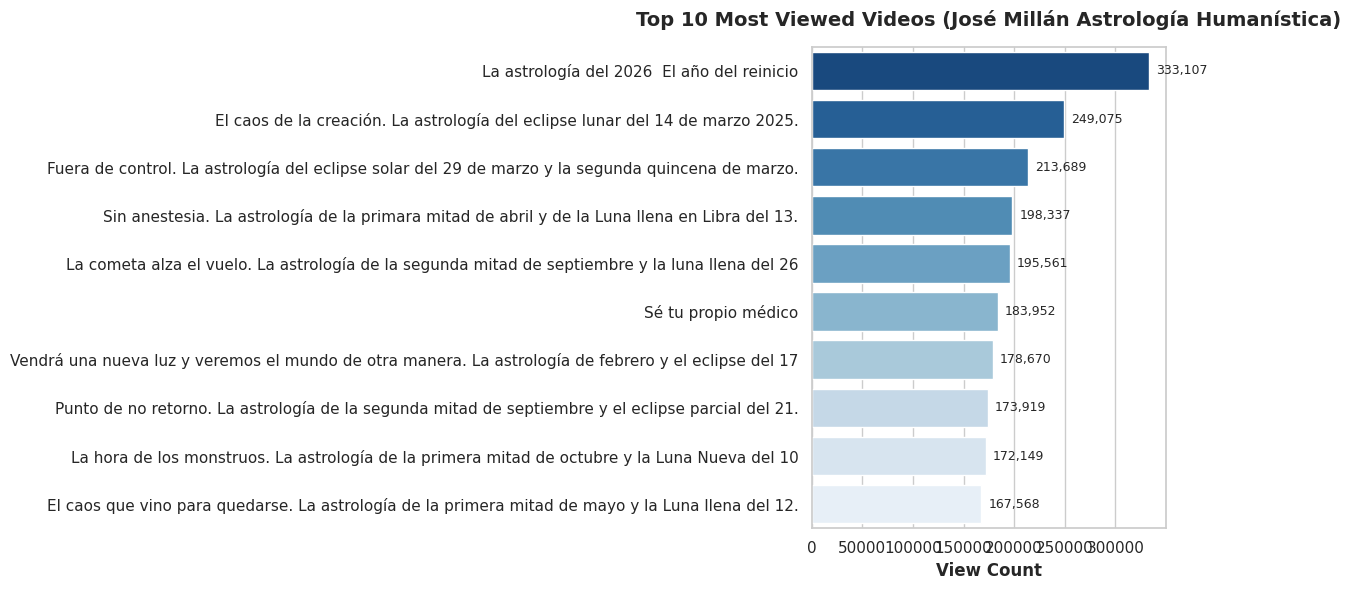

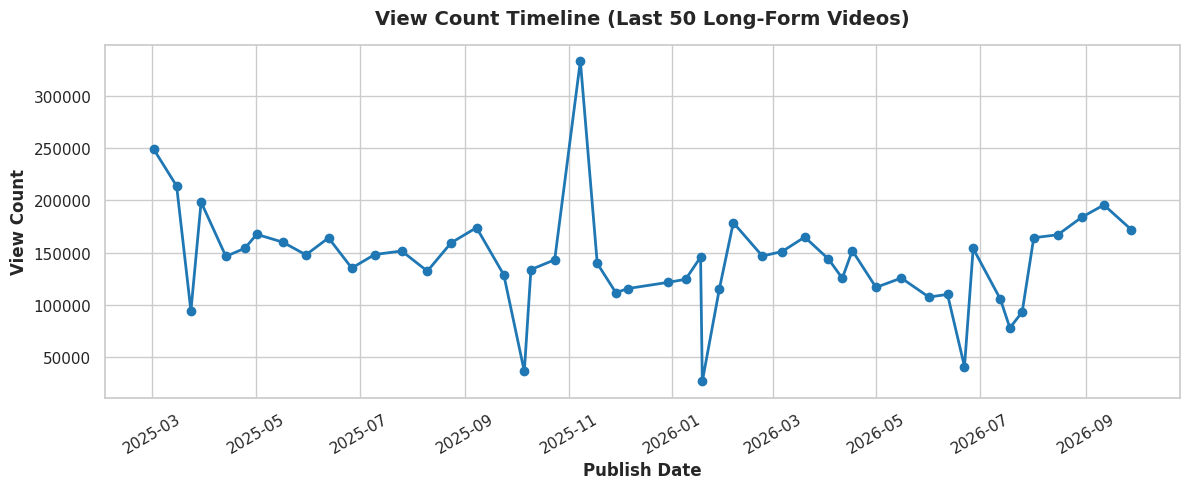

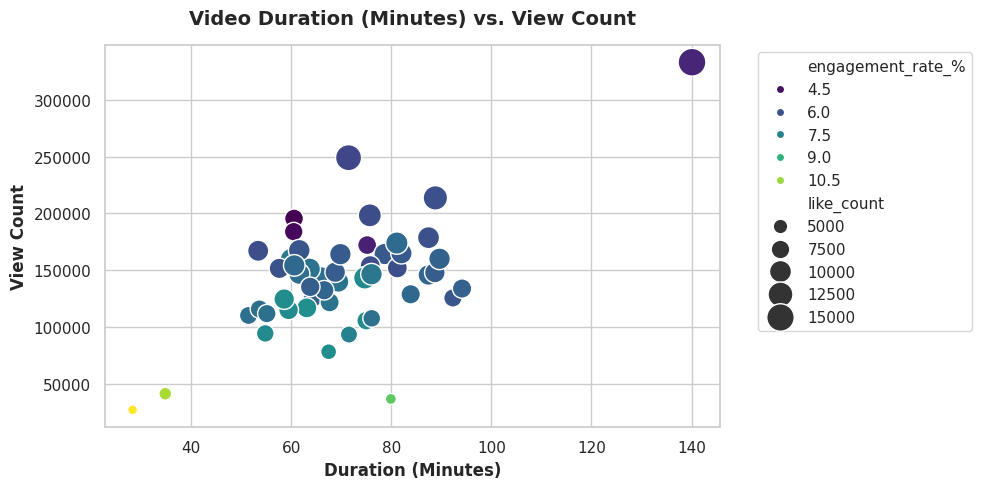

/tmp/ipykernel_961/2075797857.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="title", y="engagement_rate_%", data=top_10, palette="Greens_r")
/tmp/ipykernel_961/2075797857.py:60: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


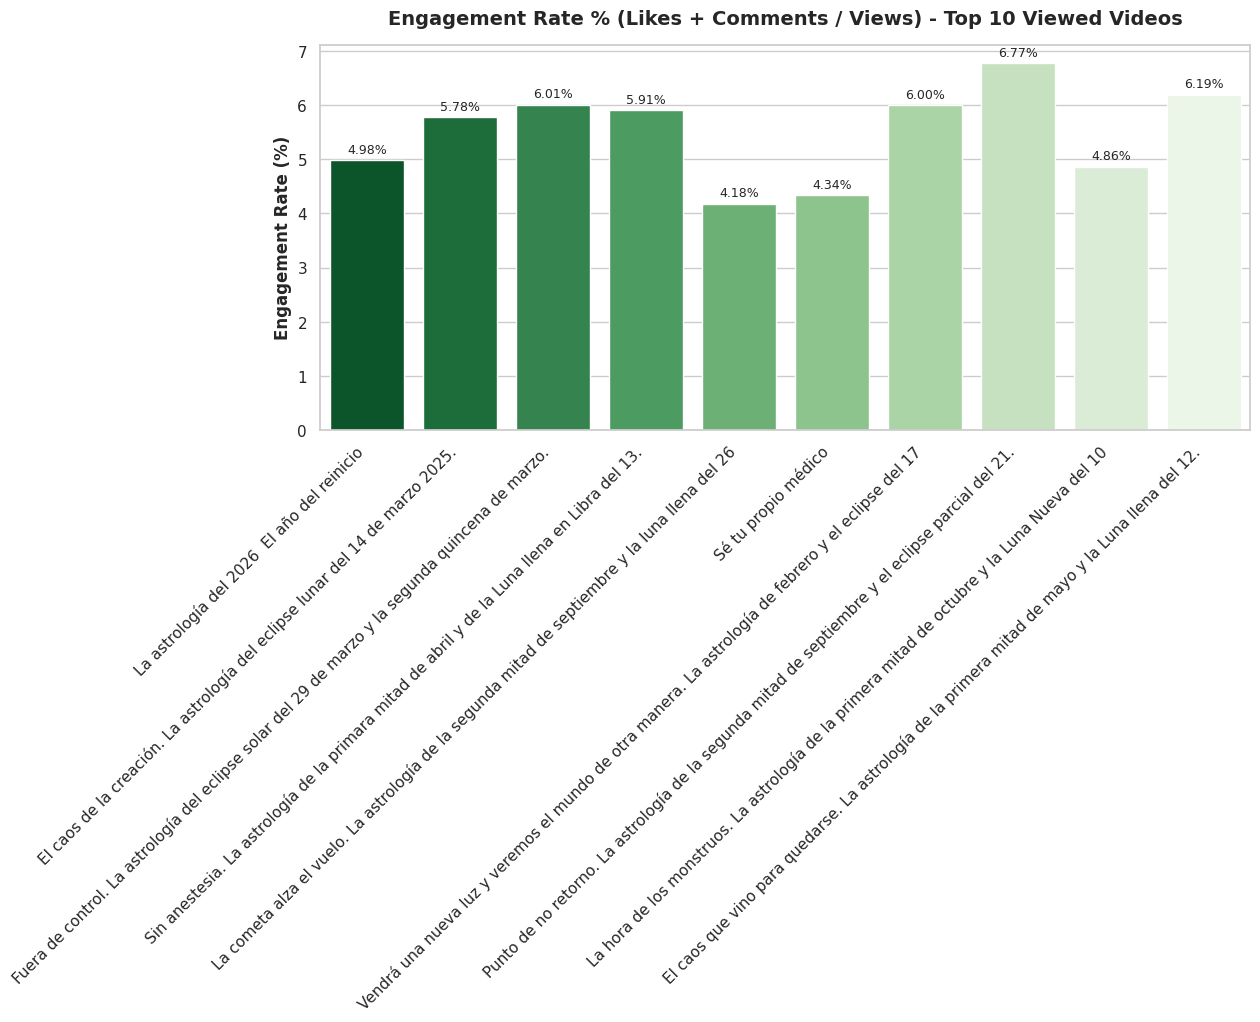

/tmp/ipykernel_961/2075797857.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=day_counts.index, y=day_counts.values, palette="magma")


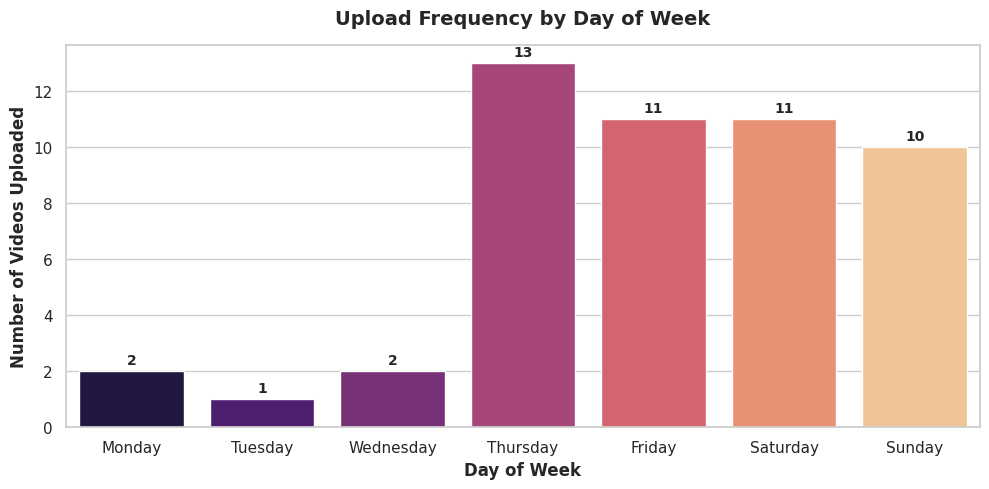

In [12]:
# Set overall plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 10, 'figure.titlesize': 14})

# Chart 1: Top 10 Most Viewed Long-Form Videos
plt.figure(figsize=(12, 6))
top_10 = df.sort_values(by="view_count", ascending=False).head(10)
ax = sns.barplot(x="view_count", y="title", data=top_10, palette="Blues_r")
plt.title(f"Top 10 Most Viewed Videos ({channel_info['title']})", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("View Count", fontweight="bold")
plt.ylabel("")
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{int(width):,}",
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=9)
plt.tight_layout()
plt.show()

# Chart 2: Views Over Time / Upload Timeline
plt.figure(figsize=(12, 5))
df_sorted_time = df.sort_values(by="published_at_dt")
plt.plot(df_sorted_time["published_at_dt"], df_sorted_time["view_count"], marker='o', color='#1f77b4', linewidth=2, markersize=6)
plt.title(f"View Count Timeline (Last {len(df)} Long-Form Videos)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Publish Date", fontweight="bold")
plt.ylabel("View Count", fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Chart 3: Video Duration vs. View Count
plt.figure(figsize=(10, 5))
df['duration_minutes'] = df['duration_seconds'] / 60.0
sns.scatterplot(x="duration_minutes", y="view_count", size="like_count", sizes=(50, 400), hue="engagement_rate_%", data=df, palette="viridis")
plt.title("Video Duration (Minutes) vs. View Count", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Duration (Minutes)", fontweight="bold")
plt.ylabel("View Count", fontweight="bold")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Chart 4: Engagement Rate % Distribution across Videos
plt.figure(figsize=(12, 5))
ax = sns.barplot(x="title", y="engagement_rate_%", data=top_10, palette="Greens_r")
plt.title("Engagement Rate % (Likes + Comments / Views) - Top 10 Viewed Videos", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Engagement Rate (%)", fontweight="bold")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}%",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                xytext=(0, 3),
                textcoords='offset points',
                fontsize=9)
plt.tight_layout()
plt.show()

# Chart 5: Publishing Day of Week Distribution
plt.figure(figsize=(10, 5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['publish_day_of_week'].value_counts().reindex(days_order).fillna(0)
ax = sns.barplot(x=day_counts.index, y=day_counts.values, palette="magma")
plt.title("Upload Frequency by Day of Week", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Day of Week", fontweight="bold")
plt.ylabel("Number of Videos Uploaded", fontweight="bold")
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{int(height)}",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 3),
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')
plt.tight_layout()
plt.show()